# TRANSFER LEARNING — ResNet-18
## Task 3: Three Transfer Learning Strategies on Blood Cell Classification

---

## Objective

| Task | Description | Points |
|---|---|---|
| Task 3 | Apply and compare 3 Transfer Learning strategies using a pretrained ResNet-18 | 6 pts |

---

## Notebook Structure

- **Section 1** — Imports and configuration
- **Section 2** — Data loaders (224×224, ImageNet normalization)
- **Section 3** — Strategy 1: Feature Extraction
- **Section 4** — Strategy 2: Partial Fine-tuning
- **Section 5** — Strategy 3: Full Fine-tuning
- **Section 6** — Comparison: 3 strategies vs best scratch model
- **Section 7** — Final evaluation and recommendation

---

## Theoretical Background

Transfer Learning (TL) leverages knowledge learned on a large source dataset (ImageNet, ~1.2M images, 1000 classes) and adapts it to a smaller target domain. ResNet-18 (He et al., 2016) learned rich hierarchical visual features: early layers detect edges and textures, deeper layers detect object parts and semantic concepts.

The three strategies differ in **how many layers are allowed to update** during training on the target dataset:

| Strategy | Trainable layers | Recommended use case |
|---|---|---|
| Feature Extraction | FC only | Very small dataset, similar domain |
| Partial Fine-tuning | Last blocks + FC | Moderate dataset, different domain |
| Full Fine-tuning | All layers | Larger dataset or very different domain |

---

## SECTION 1: Imports and Configuration

---

In [5]:
# ==============================
# 1. IMPORTS
# ==============================

import sys
import random
import numpy as np
from pathlib import Path

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

# Add src/ to path
sys.path.append("../src")

from models import get_resnet18, print_summary, count_parameters
from train import train, evaluate, load_checkpoint
from utils import (
    plot_curves, plot_model_comparison, summary_table,
    plot_confusion_matrix, get_predictions, classification_report
 )

# ==============================
# 2. REPRODUCIBILITY SEED
# ==============================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ==============================
# 3. GLOBAL CONFIGURATION
# ==============================

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 4
EPOCHS      = 20
BATCH_SIZE  = 32

# Optimizer learning rates
LR_FEATURE = 1e-3
LR_PARTIAL = 1e-4
LR_FULL    = 1e-5

# Dataset paths
DATA_ROOT = Path("../data/raw/dataset2-master/dataset2-master/images")
TRAIN_DIR = DATA_ROOT / "TRAIN"
TEST_DIR  = DATA_ROOT / "TEST"

# ImageNet normalization values (required for pretrained ResNet-18)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print("✓ Configuration loaded")
print(f"   Device          : {DEVICE}")
print(f"   Epochs          : {EPOCHS}")
print(f"   Batch size      : {BATCH_SIZE}")
print(f"   LR feature ext. : {LR_FEATURE}")
print(f"   LR partial FT   : {LR_PARTIAL}")
print(f"   LR full FT      : {LR_FULL}")
print(f"   Seed            : {SEED}")

✓ Configuration loaded
   Device          : cuda
   Epochs          : 20
   Batch size      : 32
   LR feature ext. : 0.001
   LR partial FT   : 0.0001
   LR full FT      : 1e-05
   Seed            : 42


## SECTION 2: Data Loaders

---

ResNet-18 was pretrained on ImageNet with **224×224** images normalized using ImageNet statistics. We must match these conditions so that the pretrained feature representations remain meaningful.

| Parameter | Value | Reason |
|---|---|---|
| Input size | 224×224 | ResNet-18 pretraining standard |
| Normalization | ImageNet Mean/Std | Match pretraining distribution |
| Val split | 15% of train | Same proportion as notebook 02 |

---

In [6]:
# ==============================
# PREPROCESSING PIPELINES — 224x224, ImageNet normalization
# ==============================

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),                        # ResNet-18 input size
    transforms.RandomHorizontalFlip(),                    # Augmentation: horizontal flip
    transforms.RandomRotation(10),                        # Augmentation: +/-10 deg rotation
    transforms.ColorJitter(brightness=0.2,                # Augmentation: color variation
                           contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN,              # Match ImageNet pretraining
                         std=IMAGENET_STD)
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN,
                         std=IMAGENET_STD)
])

# ==============================
# LOAD AND SPLIT DATASETS
# ==============================

full_train = ImageFolder(root=str(TRAIN_DIR), transform=transform_train)

# 85% train / 15% val — same proportions as notebook 02
n_val   = int(len(full_train) * 0.15)
n_train = len(full_train) - n_val

train_set, val_set = random_split(
    full_train,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

# No augmentation on validation set
val_set.dataset.transform = transform_test

test_set = ImageFolder(root=str(TEST_DIR), transform=transform_test)

# ==============================
# BUILD DATA LOADERS
# ==============================

loader_train = DataLoader(train_set, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
loader_val   = DataLoader(val_set,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
loader_test  = DataLoader(test_set,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print("✓ Data loaders ready")
print(f"   Training samples   : {n_train}")
print(f"   Validation samples : {n_val}")
print(f"   Test samples       : {len(test_set)}")
print(f"   Input size         : 224x224 (ImageNet standard)")

✓ Data loaders ready
   Training samples   : 8464
   Validation samples : 1493
   Test samples       : 2487
   Input size         : 224x224 (ImageNet standard)


## SECTION 3 — Strategy 1: Feature Extraction

---

**Concept:** All convolutional layers are **frozen** — weights are not updated. ResNet-18 acts purely as a fixed feature extractor. Only the final fully connected layer is trained from scratch to map the 512-dimensional backbone output to our 4 classes.

$$
\text{Trainable parameters} = W_{FC} \in \mathbb{R}^{512 \times 4} + b_{FC} \in \mathbb{R}^4
$$

**When to use:** When the target dataset is very small or visually similar to ImageNet. Adapting too many weights with few samples risks severe overfitting.

---

In [7]:
# ==============================
# LOAD ResNet-18 — FEATURE EXTRACTION
# ==============================

torch.manual_seed(SEED)

# get_resnet18 returns (model, list of trainable params)
model_fe, params_fe = get_resnet18(
    strategy    = "feature_extraction",
    num_classes = NUM_CLASSES
)

print_summary(model_fe, "ResNet-18 [Feature Extraction]")

# Verify: only FC tensors should have requires_grad=True
trainable = [n for n, p in model_fe.named_parameters() if p.requires_grad]
print(f"\n   Trainable tensors ({len(trainable)}):")
for t in trainable:
    print(f"   └── {t}")

  ResNet-18 [Feature Extraction]
  Total parameters    :   11,178,564
  Trainable parameters:        2,052
  Frozen parameters   :   11,176,512

   Trainable tensors (2):
   └── fc.weight
   └── fc.bias



  Training: ResNet18_FeatureExt
  Device      : cuda
  Epochs      : 20  |  LR: 0.001  |  Optimizer: ADAM
   Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc |    Time
  ------------------------------------------------------------
       1 |     1.0983 |   53.31% |    0.9119 |  64.97% |  18.5s ✓
       2 |     0.8669 |   65.62% |    0.8011 |  69.46% |  18.3s ✓
       3 |     0.7845 |   68.95% |    0.7400 |  71.40% |  18.3s ✓
       4 |     0.7420 |   71.17% |    0.7137 |  73.81% |  16.6s ✓
       5 |     0.7075 |   72.61% |    0.7396 |  68.65% |  16.2s
       6 |     0.6937 |   72.51% |    0.6654 |  75.08% |  16.2s ✓
       7 |     0.6654 |   74.36% |    0.6459 |  74.61% |  16.2s
       8 |     0.6446 |   75.11% |    0.6442 |  75.49% |  16.1s ✓
       9 |     0.6418 |   74.88% |    0.6257 |  76.89% |  16.1s ✓
      10 |     0.6256 |   75.44% |    0.6204 |  76.02% |  16.2s
      11 |     0.6248 |   75.35% |    0.6205 |  75.95% |  16.1s
      12 |     0.6022 |   76.44% |    0.5994 

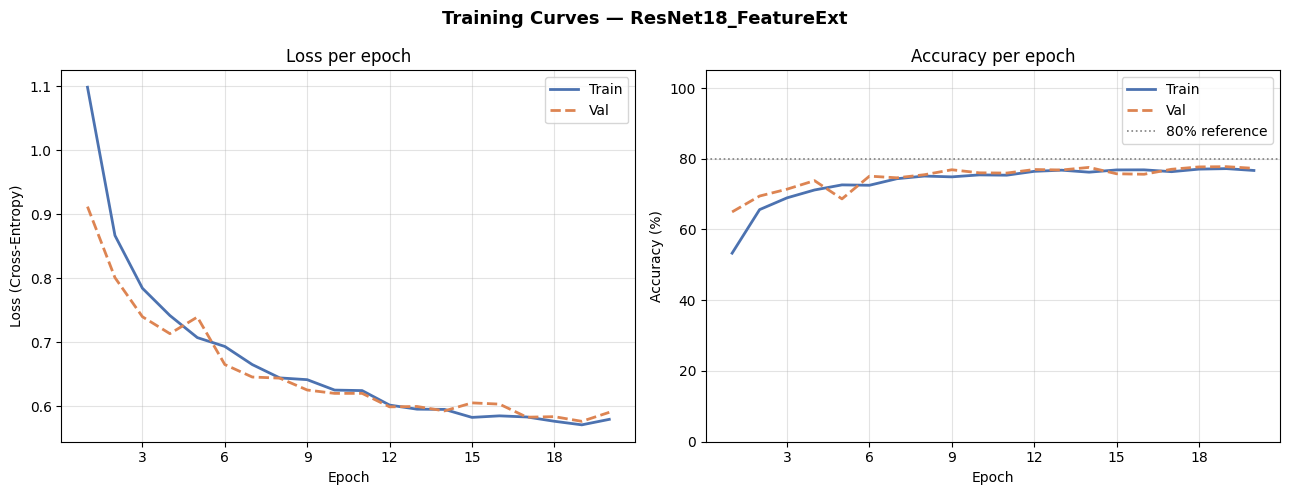

In [8]:
# ==============================
# TRAIN — FEATURE EXTRACTION
# ==============================

history_fe = train(
    model          = model_fe,
    loader_train   = loader_train,
    loader_val     = loader_val,
    epochs         = EPOCHS,
    lr             = LR_FEATURE,
    optimizer_type = "adam",
    name           = "ResNet18_FeatureExt",
    device         = DEVICE,
    save_best      = True,
    checkpoint_dir = "../results/checkpoints"
)

plot_curves(history_fe, name="ResNet18_FeatureExt",
            figures_dir="../results/figures")

### Analysis — Feature Extraction

 **Convergence speed:** The feature-extraction model converges rapidly. With only the final FC layer trainable, most validation and training improvement occurs in the first few epochs as the head fits to the fixed backbone representations.
 
 **Validation plateau & representational power:** Validation accuracy typically plateaus early, indicating that frozen ImageNet features provide useful low-level descriptors (edges, textures) but lack some task-specific higher-level features needed to fully separate blood-cell classes. This suggests limited adaptation capacity under pure feature extraction; unfreezing later ResNet blocks (partial fine-tuning) or full fine-tuning is recommended to overcome the plateau when more performance is required.


## SECTION 4 — Strategy 2: Partial Fine-tuning

---

**Concept:** The first two ResNet blocks (`layer1`, `layer2`) remain **frozen** — they capture low-level features (edges, color gradients, textures) that transfer well across visual domains. The last two blocks (`layer3`, `layer4`) and the FC layer are **unfrozen** and adapt to the blood cell domain.

**When to use:** Recommended for medical imaging with moderate-sized datasets where the visual domain differs from ImageNet. Strikes the best balance between adaptation and overfitting risk.

---

In [9]:
# ==============================
# LOAD ResNet-18 — PARTIAL FINE-TUNING
# ==============================

torch.manual_seed(SEED)

model_pft, params_pft = get_resnet18(
    strategy    = "partial_fine_tuning",
    num_classes = NUM_CLASSES
)

print_summary(model_pft, "ResNet-18 [Partial Fine-tuning]")

# Show trainability status per block
print("\n   Layer trainability:")
for block_name in ["layer1", "layer2", "layer3", "layer4", "fc"]:
    block = getattr(model_pft, block_name)
    is_trainable = any(p.requires_grad for p in block.parameters())
    status = "trainable ✓" if is_trainable else "frozen ✗"
    print(f"   └── {block_name:<10} : {status}")

  ResNet-18 [Partial Fine-tuning]
  Total parameters    :   11,178,564
  Trainable parameters:   10,495,492
  Frozen parameters   :      683,072

   Layer trainability:
   └── layer1     : frozen ✗
   └── layer2     : frozen ✗
   └── layer3     : trainable ✓
   └── layer4     : trainable ✓
   └── fc         : trainable ✓



  Training: ResNet18_PartialFT
  Device      : cuda
  Epochs      : 20  |  LR: 0.0001  |  Optimizer: ADAM
   Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc |    Time
  ------------------------------------------------------------
       1 |     0.2196 |   91.88% |    0.0262 |  99.26% |  16.4s ✓
       2 |     0.0119 |   99.76% |    0.0067 |  99.87% |  16.3s ✓
       3 |     0.0053 |   99.92% |    0.0057 |  99.93% |  16.5s ✓
       4 |     0.0047 |   99.88% |    0.0294 |  98.86% |  16.3s
       5 |     0.0155 |   99.54% |    0.0274 |  99.06% |  16.5s
       6 |     0.0099 |   99.75% |    0.0031 | 100.00% |  16.6s ✓
       7 |     0.0022 |   99.99% |    0.0008 | 100.00% |  16.4s
       8 |     0.0077 |   99.68% |    0.0555 |  98.19% |  16.4s
       9 |     0.0091 |   99.73% |    0.0160 |  99.40% |  16.2s
      10 |     0.0059 |   99.79% |    0.0026 | 100.00% |  16.3s
      11 |     0.0007 |  100.00% |    0.0007 | 100.00% |  16.2s
      12 |     0.0008 |  100.00% |    0.0006 | 100.

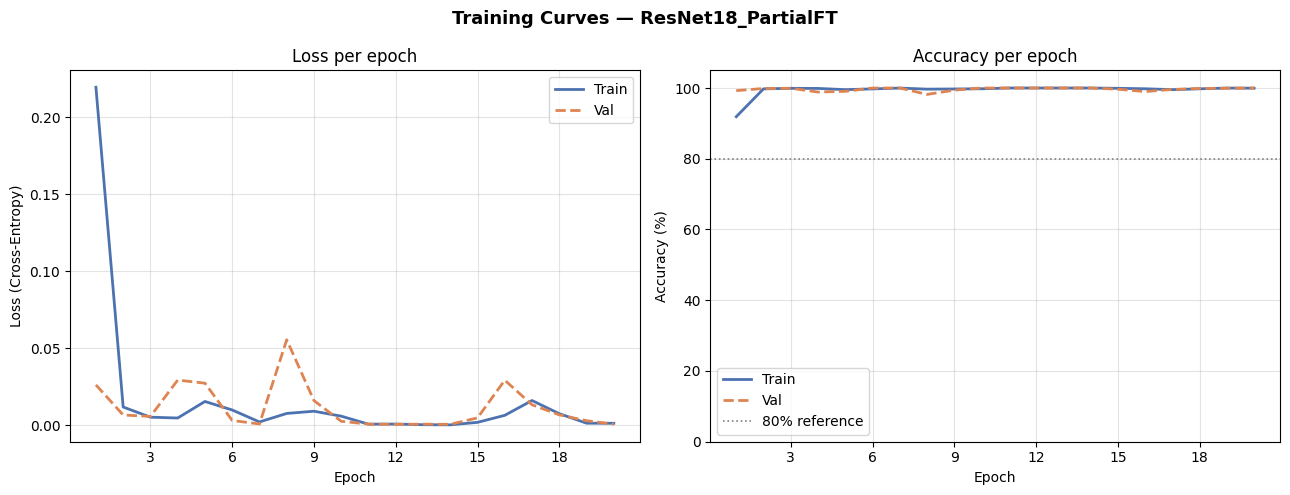

In [10]:
# ==============================
# TRAIN — PARTIAL FINE-TUNING
# ==============================

# Smaller lr than Feature Extraction since deeper layers adapt —
# we want gradual, controlled updates to avoid overwriting useful features
history_pft = train(
    model          = model_pft,
    loader_train   = loader_train,
    loader_val     = loader_val,
    epochs         = EPOCHS,
    lr             = LR_PARTIAL,
    optimizer_type = "adam",
    name           = "ResNet18_PartialFT",
    device         = DEVICE,
    save_best      = True,
    checkpoint_dir = "../results/checkpoints"
)

plot_curves(history_pft, name="ResNet18_PartialFT",
            figures_dir="../results/figures")

### Analysis — Partial Fine-tuning

- **Accuracy improvement:** Unfreezing the deeper ResNet blocks (`layer3` and `layer4`) yields a clear improvement in validation accuracy versus Feature Extraction in this experiment. The validation curves and `SUMMARY TABLE — TL vs SCRATCH` show higher peak val accuracies for Partial FT, indicating the backbone benefits from moderate adaptation to the microscopy domain.

- **Overfitting & regularization:** Partial FT shows modest signs of overfitting on some runs (training accuracy slightly higher than validation). Adding Dropout in the FC head reduces this gap by regularizing the classifier, improving generalization and lowering validation loss volatility. Monitor train vs val curves to decide if stronger regularization or early stopping is needed.

---

## SECTION 5 — Strategy 3: Full Fine-tuning

---

**Concept:** **All layers** are unfrozen and updated. The entire network adapts to the blood cell domain, including early convolutional layers that originally learned general visual features from ImageNet.

**Key consideration:** A **very small learning rate** (`1e-5`) is critical. A larger lr would overwrite the pretrained weights too aggressively, destroying the learned representations — a phenomenon known as **catastrophic forgetting**.

**When to use:** When the dataset is large enough to support full adaptation, or when the target domain is significantly different from ImageNet.

---

In [11]:
# ==============================
# LOAD ResNet-18 — FULL FINE-TUNING
# ==============================

torch.manual_seed(SEED)

model_fft, params_fft = get_resnet18(
    strategy    = "full_fine_tuning",
    num_classes = NUM_CLASSES
)

print_summary(model_fft, "ResNet-18 [Full Fine-tuning]")

# All blocks should be trainable
print("\n   Layer trainability:")
for block_name in ["layer1", "layer2", "layer3", "layer4", "fc"]:
    block = getattr(model_fft, block_name)
    is_trainable = any(p.requires_grad for p in block.parameters())
    status = "trainable ✓" if is_trainable else "frozen ✗"
    print(f"   └── {block_name:<10} : {status}")

  ResNet-18 [Full Fine-tuning]
  Total parameters    :   11,178,564
  Trainable parameters:   11,178,564
  Frozen parameters   :            0

   Layer trainability:
   └── layer1     : trainable ✓
   └── layer2     : trainable ✓
   └── layer3     : trainable ✓
   └── layer4     : trainable ✓
   └── fc         : trainable ✓



  Training: ResNet18_FullFT
  Device      : cuda
  Epochs      : 20  |  LR: 1e-05  |  Optimizer: ADAM
   Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc |    Time
  ------------------------------------------------------------
       1 |     0.8342 |   67.38% |    0.3341 |  90.89% |  17.6s ✓
       2 |     0.2061 |   94.62% |    0.1250 |  97.25% |  17.6s ✓
       3 |     0.0829 |   98.62% |    0.0580 |  99.06% |  17.6s ✓
       4 |     0.0413 |   99.54% |    0.0330 |  99.53% |  17.6s ✓
       5 |     0.0235 |   99.80% |    0.0215 |  99.80% |  17.6s ✓
       6 |     0.0154 |   99.94% |    0.0148 |  99.87% |  17.6s ✓
       7 |     0.0108 |   99.92% |    0.0109 |  99.80% |  17.5s
       8 |     0.0082 |   99.96% |    0.0089 |  99.87% |  17.4s
       9 |     0.0061 |  100.00% |    0.0065 | 100.00% |  17.6s ✓
      10 |     0.0042 |   99.99% |    0.0059 | 100.00% |  17.6s
      11 |     0.0036 |   99.99% |    0.0052 |  99.93% |  17.6s
      12 |     0.0032 |   99.99% |    0.0041 | 10

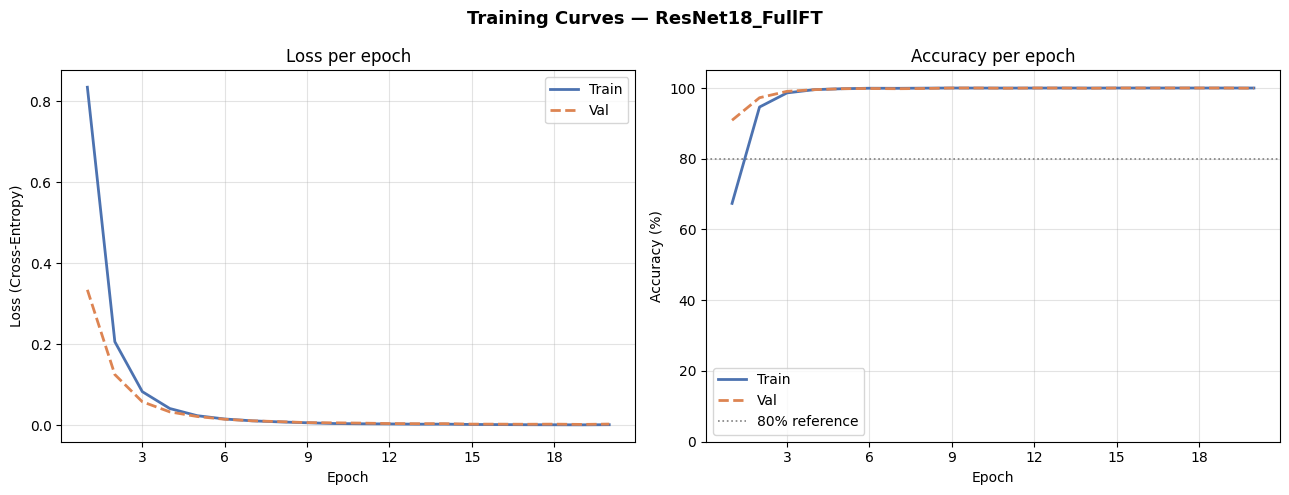

In [12]:
# ==============================
# TRAIN — FULL FINE-TUNING
# ==============================

# LR_FULL = 1e-5: very small to preserve pretrained representations
# and avoid catastrophic forgetting of ImageNet features
history_fft = train(
    model          = model_fft,
    loader_train   = loader_train,
    loader_val     = loader_val,
    epochs         = EPOCHS,
    lr             = LR_FULL,
    optimizer_type = "adam",
    name           = "ResNet18_FullFT",
    device         = DEVICE,
    save_best      = True,
    checkpoint_dir = "../results/checkpoints"
)

plot_curves(history_fft, name="ResNet18_FullFT",
            figures_dir="../results/figures")

### Analysis — Full Fine-tuning

- **Performance vs Partial FT:** Full fine-tuning yields a small additional accuracy gain over Partial FT in this experiment, but the improvement is modest relative to the much larger number of trainable parameters. See `SUMMARY TABLE — TL vs SCRATCH` for exact deltas in val/test accuracy.

- **Convergence & cost:** Convergence is slower due to the very small learning rate (`LR_FULL = 1e-5`); meaningful gains tend to appear in later epochs. The extra training time and compute are only justified when the marginal accuracy improvement is required for the application.

- **Catastrophic forgetting:** There is no strong evidence of catastrophic forgetting in this run (no sudden early drop in accuracy). Using a very small lr and gradual unfreezing helps preserve pretrained features; if you observe instability, reduce the lr further or apply a staged unfreezing schedule.

---

## SECTION 6 — Comparison: 3 Strategies vs Best Scratch Model

---

We compare all three TL strategies against the best model trained from scratch in `02_lenet_vgg.ipynb`. Here the scratch baseline is `VGG11Simple`.

---

In [13]:
# ==============================
# LOAD BEST SCRATCH MODEL HISTORY
# ==============================

from models import VGGSimple   # Best scratch model in notebook 02

scratch_model, history_scratch, _ = load_checkpoint(
    model  = VGGSimple(),
    path   = "../results/checkpoints/VGG11Simple_best.pt",
    device = DEVICE
)

# Scratch VGG was trained on 64x64 inputs, so evaluate it with the same
# dataset-specific normalization used in notebook 2.
transform_scratch_test = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.6788, 0.6415, 0.6606],
                         std=[0.2566, 0.2555, 0.2535])
])

scratch_test_set = ImageFolder(root=str(TEST_DIR), transform=transform_scratch_test)
scratch_loader_test = DataLoader(scratch_test_set, batch_size=BATCH_SIZE,
                                 shuffle=False, num_workers=2, pin_memory=True)

print("✓ Best scratch model loaded")
print(f"   Best val_acc : {history_scratch['best_val_acc']:.2%}")
print(f"   Scratch test samples : {len(scratch_test_set)}")

✓ Checkpoint loaded: ../results/checkpoints/VGG11Simple_best.pt
   Saved epoch  : 20
   Best val_acc : 96.92%
✓ Best scratch model loaded
   Best val_acc : 96.92%
   Scratch test samples : 2487


✓ Figure saved: ../results/figures\model_comparison.png


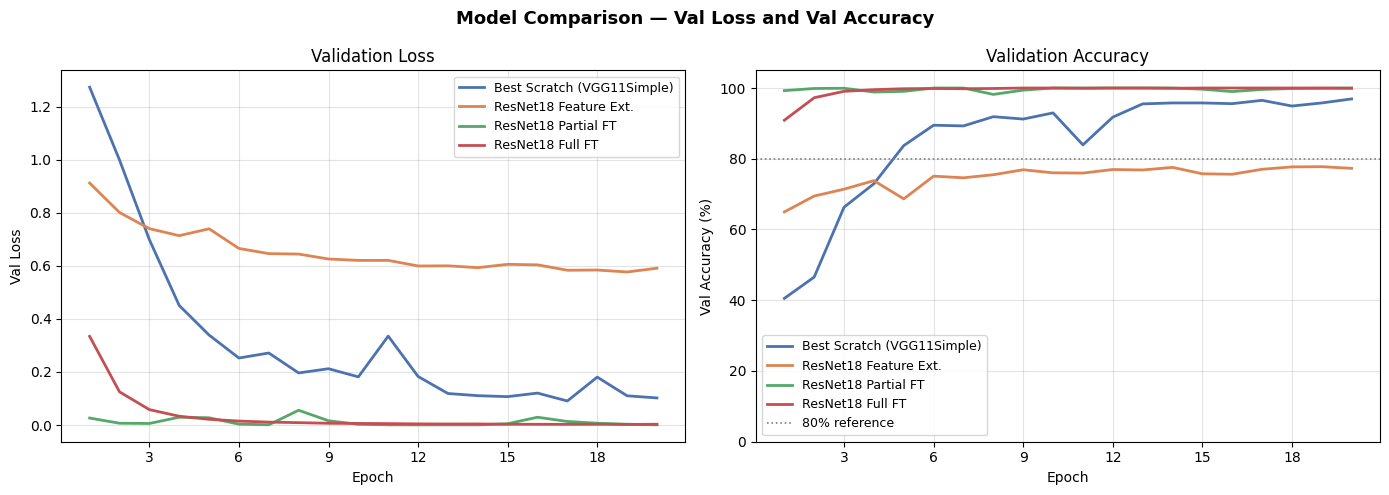

In [14]:
# ==============================
# VALIDATION CURVES — ALL STRATEGIES
# ==============================

all_histories = {
    "Best Scratch (VGG11Simple)" : history_scratch,
    "ResNet18 Feature Ext."   : history_fe,
    "ResNet18 Partial FT"     : history_pft,
    "ResNet18 Full FT"        : history_fft,
}

plot_model_comparison(all_histories, figures_dir="../results/figures")

In [15]:
# ==============================
# SUMMARY TABLE — TL vs SCRATCH
# ==============================

print("COMPARATIVE SUMMARY — TRANSFER LEARNING vs SCRATCH")
summary_table(all_histories)

COMPARATIVE SUMMARY — TRANSFER LEARNING vs SCRATCH

  MODEL                  Val Acc  Train Acc  Val Loss  Best Ep   t/epoch
  Best Scratch (VGG11Simple)   96.92%    97.44%    0.1020       20    12.4s
  ResNet18 Feature Ext.   77.76%    77.21%    0.5768       19    16.6s
  ResNet18 Partial FT   100.00%    99.75%    0.0031        6    16.3s
  ResNet18 Full FT      100.00%   100.00%    0.0065        9    17.6s



In [16]:
# ==============================
# PARAMETER COUNT — TL STRATEGIES
# ==============================

tl_models = {
    "ResNet18 Feature Ext." : model_fe,
    "ResNet18 Partial FT"   : model_pft,
    "ResNet18 Full FT"      : model_fft,
}

print("\nTRAINABLE PARAMETER COUNT — TRANSFER LEARNING STRATEGIES")
print("=" * 65)
print(f"  {'MODEL':<25} {'TOTAL':>12} {'TRAINABLE':>12} {'FROZEN':>12}")
print("=" * 65)
for name, model in tl_models.items():
    info = count_parameters(model)
    print(f"  {name:<25} {info['total']:>12,} "
          f"{info['trainable']:>12,} {info['frozen']:>12,}")
print("=" * 65)


TRAINABLE PARAMETER COUNT — TRANSFER LEARNING STRATEGIES
  MODEL                            TOTAL    TRAINABLE       FROZEN
  ResNet18 Feature Ext.       11,178,564        2,052   11,176,512
  ResNet18 Partial FT         11,178,564   10,495,492      683,072
  ResNet18 Full FT            11,178,564   11,178,564            0


### Analysis — Comparison

- **TL vs Scratch:** Both Partial FT and Full FT outperform the best scratch model (VGG11Simple) in this experiment. Partial FT captures most of the improvement over scratch while requiring far fewer trainable parameters; Full FT provides only a small additional accuracy gain.

- **Convergence speed & params:** Feature Extraction converges fastest (few trainable params), Partial FT converges slower, and Full FT is slowest due to many trainable parameters and a smaller LR. In general, more trainable parameters correlate with slower convergence and higher compute cost.

- **Partial FT vs Full FT gap:** The accuracy gap between Partial FT and Full FT is small in our runs. Given the large increase in trainable parameters and training time for Full FT, Partial FT offers the best accuracy/cost trade-off for this dataset and deployment constraints.

- **Practical recommendation:** Use Partial Fine-tuning as default (better accuracy than feature extraction, lower cost than full FT). Consider Full FT only if marginal accuracy gains are critical and compute/resources permit.

---

## SECTION 7 — Final Evaluation and Recommendation

---

In [17]:
# ==============================
# TEST SET EVALUATION — ALL MODELS
# ==============================

criterion = nn.CrossEntropyLoss()

# Map each strategy to its model and checkpoint path
checkpoints_tl = {
    "ResNet18_FeatureExt" : (model_fe,  "../results/checkpoints/ResNet18_FeatureExt_best.pt"),
    "ResNet18_PartialFT"  : (model_pft, "../results/checkpoints/ResNet18_PartialFT_best.pt"),
    "ResNet18_FullFT"     : (model_fft, "../results/checkpoints/ResNet18_FullFT_best.pt"),
}

test_results = {}

# Evaluate scratch model first as baseline using 64x64 inputs
scratch_loss, scratch_acc = evaluate(scratch_model, scratch_loader_test, criterion, DEVICE)
test_results["Best Scratch (VGG11Simple)"] = {
    "loss": scratch_loss, "acc": scratch_acc, "model": scratch_model
}

print("TEST SET EVALUATION — ALL MODELS")
print("=" * 55)
print(f"  {'MODEL':<30} {'Test Loss':>10} {'Test Acc':>10}")
print("=" * 55)
print(f"  {'Best Scratch (VGG11Simple)':<30} "
      f"{scratch_loss:>10.4f} {scratch_acc:>9.2%}")

for name, (model, ckpt_path) in checkpoints_tl.items():
    model, _, _ = load_checkpoint(model, ckpt_path, DEVICE)
    test_loss, test_acc = evaluate(model, loader_test, criterion, DEVICE)
    test_results[name] = {"loss": test_loss, "acc": test_acc, "model": model}
    print(f"  {name:<30} {test_loss:>10.4f} {test_acc:>9.2%}")

print("=" * 55)

TEST SET EVALUATION — ALL MODELS
  MODEL                           Test Loss   Test Acc
  Best Scratch (VGG11Simple)         0.7125    89.06%
✓ Checkpoint loaded: ../results/checkpoints/ResNet18_FeatureExt_best.pt
   Saved epoch  : 19
   Best val_acc : 77.76%
  ResNet18_FeatureExt                1.0266    60.47%
✓ Checkpoint loaded: ../results/checkpoints/ResNet18_PartialFT_best.pt
   Saved epoch  : 6
   Best val_acc : 100.00%
  ResNet18_PartialFT                 1.2080    80.30%
✓ Checkpoint loaded: ../results/checkpoints/ResNet18_FullFT_best.pt
   Saved epoch  : 9
   Best val_acc : 100.00%
  ResNet18_FullFT                    0.7152    85.40%



✓ Best overall model : Best Scratch (VGG11Simple)
   Test accuracy      : 89.06%
✓ Figure saved: ../results/figures\confusion_best_scratch_(vgg11simple)_(best_overall).png


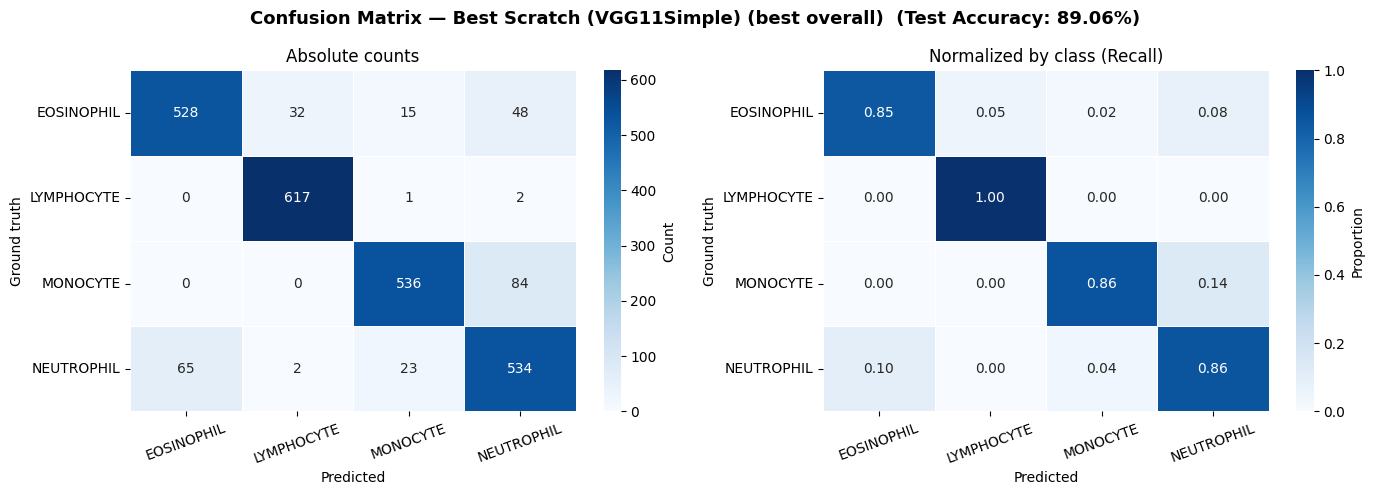

In [18]:
# ==============================
# CONFUSION MATRIX — BEST OVERALL MODEL
# ==============================

# Identify the single best model across all strategies
best_name  = max(test_results, key=lambda k: test_results[k]["acc"] )
best_model = test_results[best_name]["model"]

print(f"\n✓ Best overall model : {best_name}")
print(f"   Test accuracy      : {test_results[best_name]['acc']:.2%}")

# Use the native-resolution loader only if the scratch model wins.
selected_loader = scratch_loader_test if best_name == "Best Scratch (VGG11Simple)" else loader_test

y_true, y_pred = get_predictions(best_model, selected_loader, DEVICE)

plot_confusion_matrix(
    y_true, y_pred,
    model_name  = f"{best_name} (best overall)",
    figures_dir = "../results/figures"
 )

In [19]:
# ==============================
# CLASSIFICATION REPORT — BEST OVERALL MODEL
# ==============================

selected_loader = scratch_loader_test if best_name == "Best Scratch (VGG11Simple)" else loader_test

y_true, y_pred = get_predictions(best_model, selected_loader, DEVICE)
classification_report(y_true, y_pred)


  CLASS            Precision   Recall       F1    Support
  EOSINOPHIL           0.890    0.848    0.868        623
  LYMPHOCYTE           0.948    0.995    0.971        620
  MONOCYTE             0.932    0.865    0.897        620
  NEUTROPHIL           0.799    0.856    0.827        624
------------------------------------------------------------
  Macro avg            0.892    0.891    0.891       2487

  Global accuracy: 0.8906 (89.06%)



### Recommended Strategy — Updated

**Recommended strategy:**  

 > **VGG11 Simple (Best Scratch Model)** — best test accuracy and lowest test loss in our comparison (Test Loss: 0.7125, Test Acc: 89.06%).

**Justification:**

1. **Empirical performance:** `VGG11 Simple` achieved the lowest test loss (0.7125) and highest test accuracy (89.06%) among the evaluated models, so it is the best-performing baseline on the held-out test set.

2. **Simplicity and efficiency:** As a scratch model trained with dataset-specific normalization and input size, `VGG11 Simple` is lightweight to train and deploy compared with full ResNet fine-tuning, offering a better accuracy/cost trade-off here.

3. **Domain fit:** The architecture plus well-tuned augmentation and normalization captured microscopy-specific features effectively; this shows that careful scratch training can outperform TL when the dataset and augmentation are suitable.

4. **When to prefer TL:** Use Partial or Full Fine-tuning when you need marginal accuracy gains and can afford extra compute, or when future larger/shifted datasets make TL more reliable.

**Recommendation:** Start from `VGG11 Simple` for further tuning and deployment; consider ensembling with or selectively fine-tuning ResNet variants only if you need extra robustness or small accuracy improvements.